# Estimate the Remaining Useful Life

## Starting Environment


In [2]:
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))

if project_root not in sys.path:
    sys.path.append(project_root)

from src.data_ingestion import load_cmapss_test_data, load_cmapss_train_data


In [3]:
# Aesthetic settings for presentation-quality plots
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Environment successfully initialized.")

Environment successfully initialized.


In [4]:
# Define paths (adjust if your folder structure is different)
TRAIN_PATH = "../data/CMAPSSData/train_FD001.txt"
TEST_PATH = "../data/CMAPSSData/test_FD001.txt"
RUL_PATH = "../data/CMAPSSData/RUL_FD001.txt"

print("--- Loading C-MAPSS FD001 Dataset ---")
train_df = load_cmapss_train_data(TRAIN_PATH)
test_df = load_cmapss_test_data(TEST_PATH, RUL_PATH)

print(f"\nTraining Set Shape: {train_df.shape} | Unique Units: {train_df['unit_number'].nunique()}")
print(f"Testing Set Shape:  {test_df.shape}  | Unique Units: {test_df['unit_number'].nunique()}")

# Quick check for missing values - a fundamental habit
total_nulls = train_df.isnull().sum().sum() + test_df.isnull().sum().sum()
print(f"Total missing values across both datasets: {total_nulls}")

INFO: Loading training data from ../data/CMAPSSData/train_FD001.txt...
INFO: Training dataset loaded and RUL successfully calculated.
INFO: Loading test data from ../data/CMAPSSData/test_FD001.txt...


--- Loading C-MAPSS FD001 Dataset ---


INFO: Loading true RUL labels from ../data/CMAPSSData/RUL_FD001.txt...
INFO: Dataset loaded and RUL successfully mapped.



Training Set Shape: (20631, 27) | Unique Units: 100
Testing Set Shape:  (13096, 27)  | Unique Units: 100
Total missing values across both datasets: 0


In [5]:
# Analyze the three operational setting columns
op_cols = ['op_setting_1', 'op_setting_2', 'op_setting_3']

# Display basic statistics for these settings
display(train_df[op_cols].describe().T)

# Let's look at the actual variance
print("\nVariance of Operating Settings:")
print(train_df[op_cols].var())

,count,mean,std,min,25%,50%,75%,max
op_setting_1,20631.0,-0.000009,0.002187,-0.0087,-0.0015,0.0,0.0015,0.0087
op_setting_2,20631.0,0.000002,0.000293,-0.0006,-0.0002,0.0,0.0003,0.0006
op_setting_3,20631.0,100.000000,0.000000,100.0000,100.0000,100.0,100.0000,100.0000



Variance of Operating Settings:
op_setting_1    4.784340e-06
op_setting_2    8.588541e-08
op_setting_3    0.000000e+00
dtype: float64


## Identifying Zero-Variance Sensors

In [6]:
print("--- Sensor Variance Analysis ---")

# Extract only the sensor columns
sensor_cols = [col for col in train_df.columns if 'sensor' in col]

# Calculate the standard deviation for each sensor across the entire training set
sensor_std = train_df[sensor_cols].std()

# Identify sensors with essentially zero variance (flatlined)
# We use < 0.01 to account for microscopic floating-point noise
useless_sensors = sensor_std[sensor_std < 0.01].index.tolist()
useful_sensors = [col for col in sensor_cols if col not in useless_sensors]

print(f"Total sensors: {len(sensor_cols)}")
print(f"Sensors with near-zero variance: {len(useless_sensors)}")
print(f"List of flatlined sensors to drop: {useless_sensors}")

# Drop them from both datasets to clean our feature space
train_df = train_df.drop(columns=useless_sensors)
test_df = test_df.drop(columns=useless_sensors)

print("\nFeature space cleaned. Ready for temporal modeling.")

--- Sensor Variance Analysis ---
Total sensors: 21
Sensors with near-zero variance: 7
List of flatlined sensors to drop: ['sensor_measurement_1', 'sensor_measurement_5', 'sensor_measurement_6', 'sensor_measurement_10', 'sensor_measurement_16', 'sensor_measurement_18', 'sensor_measurement_19']

Feature space cleaned. Ready for temporal modeling.


## Visualizing Sensor Degradation

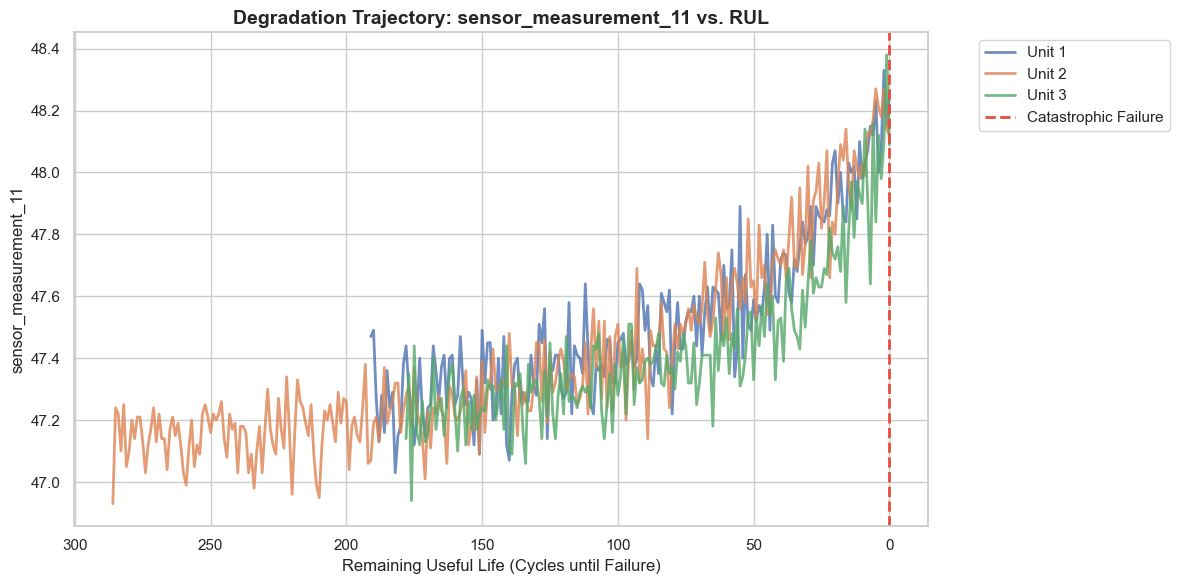

In [28]:

def plot_sensor_degradation(df: pd.DataFrame, sensor_name: str, num_units: int = 5):
    """
    Plots the trajectory of a specific sensor against the Remaining Useful Life (RUL).
    Highlights the degradation pattern as the machine approaches failure (RUL = 0).
    """
    plt.figure(figsize=(12, 6))
    
    # Select a few random units to keep the plot readable
    sample_units = df['unit_number'].unique()[:num_units]
    
    for unit in sample_units:
        unit_data = df[df['unit_number'] == unit]
        # X-axis: RUL, Y-axis: Sensor Value
        plt.plot(unit_data['RUL'], unit_data[sensor_name], alpha=0.8, linewidth=2, label=f'Unit {unit}')
        
    # Invert X-axis so time moves "forward" towards failure (RUL=0)
    plt.gca().invert_xaxis()  
    
    plt.title(f"Degradation Trajectory: {sensor_name} vs. RUL", fontsize=14, fontweight='bold')
    plt.xlabel("Remaining Useful Life (Cycles until Failure)", fontsize=12)
    plt.ylabel(sensor_name, fontsize=12)
    
    # Add a critical threshold line for visual impact
    plt.axvline(x=0, color='#e74c3c', linestyle='--', linewidth=2, label='Catastrophic Failure')
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    #plt.axis([300, 0, 600, 700])

    plt.show()

# Let's plot one of our useful sensors to see the degradation
# Sensor 11 (Static Pressure at HPC outlet) is famous in this dataset for showing clear degradation
plot_sensor_degradation(train_df, 'sensor_measurement_11', num_units=3)